Aguardando upload do arquivo 'abt_churn.csv'...


Saving abt_churn.csv to abt_churn.csv

[S] Amostragem concluída. Treino: 4154, Teste: 1039, OOT: 303


/tmp/ipykernel_7643/2399097053.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y_train.value_counts().index, y=y_train.value_counts(normalize=True).values, ax=ax[1], palette='pastel')


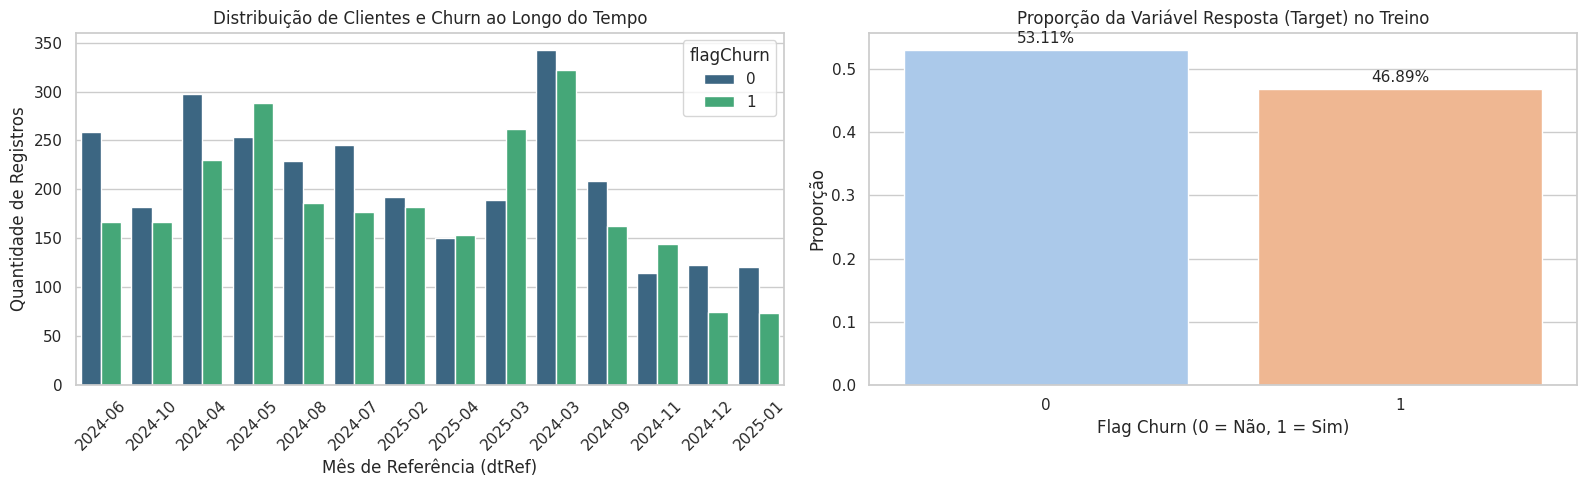

/tmp/ipykernel_7643/2399097053.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')


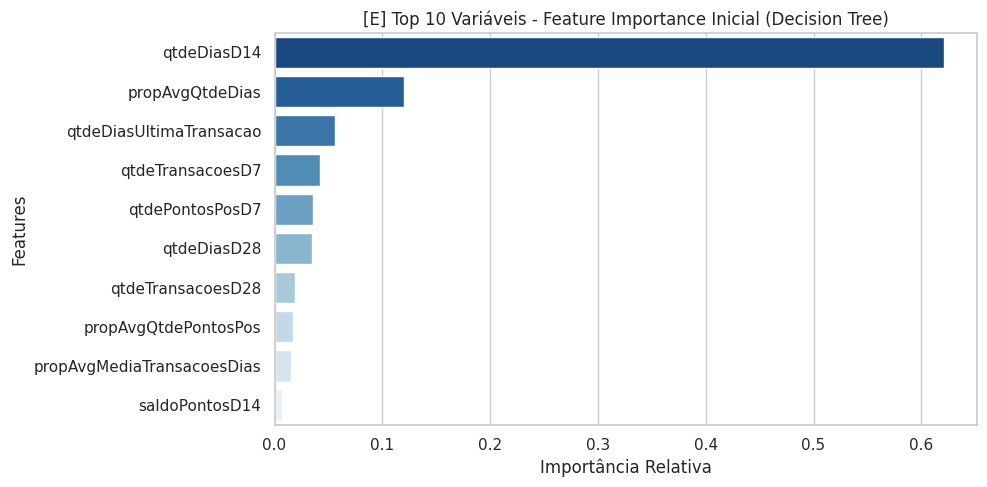


[M] Iniciando Modelagem e Tuning (GridSearch)...
Melhores parâmetros: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

[A] Resultados Finais:
Métricas Treino -> ROC AUC: 0.8433 | Acurácia: 0.7595
Métricas Teste -> ROC AUC: 0.8290 | Acurácia: 0.7526
Métricas OOT -> ROC AUC: 0.8428 | Acurácia: 0.7723


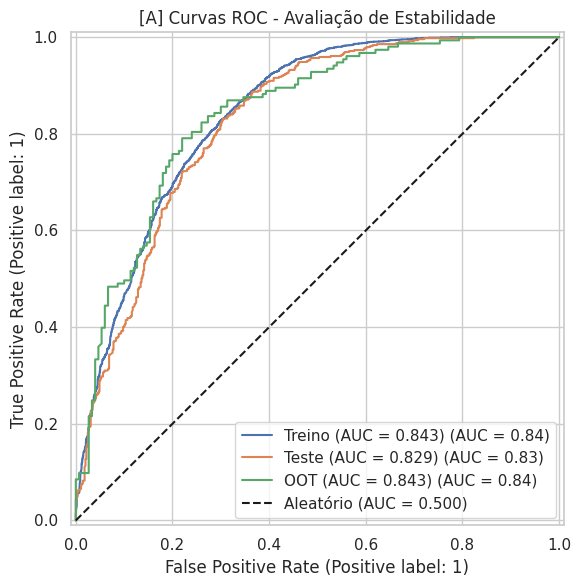

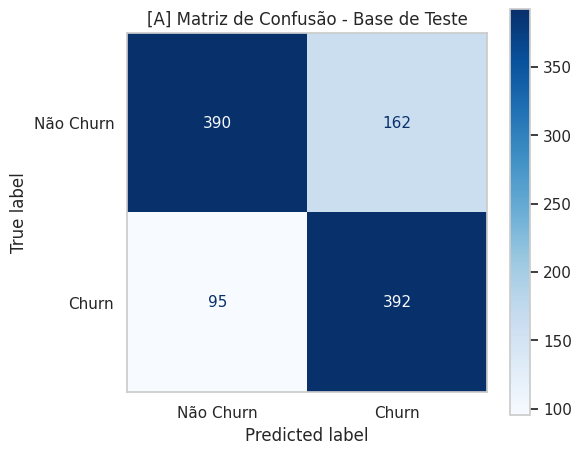

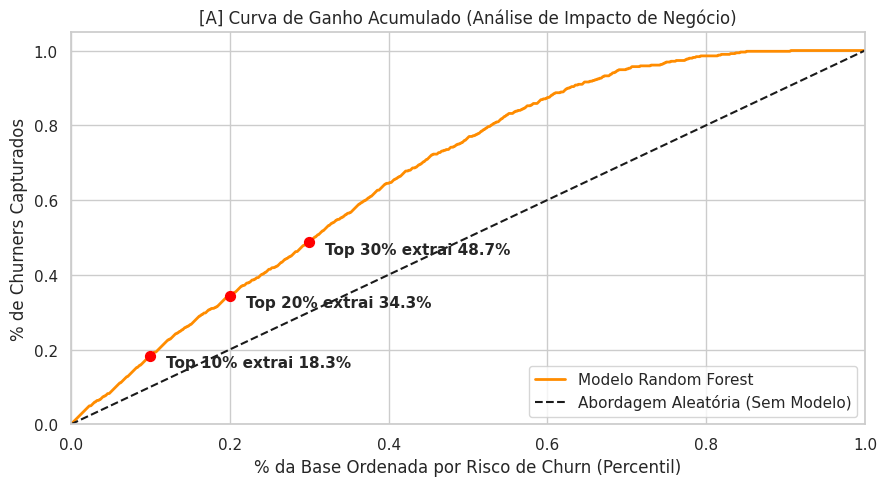


Modelo salvo como 'modelo_churn_semma.pkl'


In [1]:
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})

# 1. S - SAMPLE (Amostragem)
# ----------------------------------------------------------------
print("Aguardando upload do arquivo 'abt_churn.csv'...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Configurações de colunas baseadas no seu arquivo
col_ref = 'dtRef'
target = 'flagChurn'
col_id = 'idUsuario'

df[col_ref] = pd.to_datetime(df[col_ref])

# Out-of-Time (OOT): Reserva do último mês
data_oot = df[col_ref].max()
base_oot = df[df[col_ref] == data_oot].copy()
base_modelagem = df[df[col_ref] < data_oot].copy()

# Split Treino (80%) e Teste (20%) com Estratificação
X = base_modelagem.drop(columns=[target, col_ref, col_id])
y = base_modelagem[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\n[S] Amostragem concluída. Treino: {len(X_train)}, Teste: {len(X_test)}, OOT: {len(base_oot)}")

# Gráfico 1: Distribuição dos Dados no Tempo e Volumetria por Target
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x=df[col_ref].dt.strftime('%Y-%m'), hue=target, ax=ax[0], palette='viridis')
ax[0].set_title('Distribuição de Clientes e Churn ao Longo do Tempo')
ax[0].set_xlabel('Mês de Referência (dtRef)')
ax[0].set_ylabel('Quantidade de Registros')
ax[0].tick_params(axis='x', rotation=45)

# Gráfico da proporção do Target no treino (Verificar desbalanceamento)
sns.barplot(x=y_train.value_counts().index, y=y_train.value_counts(normalize=True).values, ax=ax[1], palette='pastel')
ax[1].set_title('Proporção da Variável Resposta (Target) no Treino')
ax[1].set_xlabel('Flag Churn (0 = Não, 1 = Sim)')
ax[1].set_ylabel('Proporção')
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), ha='center')

plt.tight_layout()
plt.show()

# 2. E - EXPLORE (Exploração)
# ----------------------------------------------------------------
# Feature Importance Inicial (Árvore de Decisão Simples)
dt_initial = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_initial.fit(X_train.fillna(0), y_train)

importances = pd.Series(dt_initial.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

# Gráfico 2: Top 10 Variáveis mais importantes (Exploração Inicial)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')
plt.title('[E] Top 10 Variáveis - Feature Importance Inicial (Decision Tree)')
plt.xlabel('Importância Relativa')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 3. M - MODIFY (Modificação) & 4. M - MODEL (Modelagem)
# ----------------------------------------------------------------
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}

print("\n[M] Iniciando Modelagem e Tuning (GridSearch)...")
grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Melhores parâmetros: {grid_search.best_params_}")

# 5. A - ASSESS (Avaliação)
# ----------------------------------------------------------------
def avaliar_modelo(nome, X_eval, y_eval):
    y_pred = best_model.predict(X_eval)
    y_proba = best_model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_eval, y_proba)
    acc = accuracy_score(y_eval, y_pred)
    print(f"Métricas {nome} -> ROC AUC: {auc:.4f} | Acurácia: {acc:.4f}")
    return auc, y_proba, y_pred

print("\n[A] Resultados Finais:")
auc_train, y_proba_train, y_pred_train = avaliar_modelo("Treino", X_train, y_train)
auc_test, y_proba_test, y_pred_test = avaliar_modelo("Teste", X_test, y_test)

X_oot = base_oot.drop(columns=[target, col_ref, col_id])
y_oot = base_oot[target]
auc_oot, y_proba_oot, y_pred_oot = avaliar_modelo("OOT", X_oot, y_oot)

# Gráfico 3: Comparativo de Curvas ROC (Treino x Teste x OOT)
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_model, X_train, y_train, ax=ax, name=f'Treino (AUC = {auc_train:.3f})')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name=f'Teste (AUC = {auc_test:.3f})')
RocCurveDisplay.from_estimator(best_model, X_oot, y_oot, ax=ax, name=f'OOT (AUC = {auc_oot:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
ax.set_title('[A] Curvas ROC - Avaliação de Estabilidade')
ax.legend()
plt.tight_layout()
plt.show()

# Gráfico 4: Matriz de Confusão (Base de Teste)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Churn', 'Churn']).plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('[A] Matriz de Confusão - Base de Teste')
ax.grid(False) # Remover linhas de grade para visualização da matriz
plt.tight_layout()
plt.show()

# Análise de Negócio (Gráfico de Ganho Acumulado / Lift)
test_results = pd.DataFrame({'prob': y_proba_test, 'real': y_test})
test_results = test_results.sort_values(by='prob', ascending=False).reset_index(drop=True)
test_results['cum_churn'] = test_results['real'].cumsum() / test_results['real'].sum()
test_results['percentil'] = (test_results.index + 1) / len(test_results)

# Gráfico 5: Curva de Ganho (Gain Chart) para Negócio
plt.figure(figsize=(9, 5))
plt.plot(test_results['percentil'], test_results['cum_churn'], label='Modelo Random Forest', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Abordagem Aleatória (Sem Modelo)')
plt.title('[A] Curva de Ganho Acumulado (Análise de Impacto de Negócio)')
plt.xlabel('% da Base Ordenada por Risco de Churn (Percentil)')
plt.ylabel('% de Churners Capturados')

# Destacar os pontos de corte solicitados no seu código anterior (10%, 20%, 30%)
for p in [0.1, 0.2, 0.3]:
    gain = test_results[test_results['percentil'] <= p]['cum_churn'].max()
    plt.scatter(p, gain, color='red', s=50, zorder=5)
    plt.annotate(f"Top {int(p*100)}% extrai {gain:.1%}", (p + 0.02, gain - 0.03), fontweight='bold')

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Serialização do modelo
import pickle
with open('modelo_churn_semma.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("\nModelo salvo como 'modelo_churn_semma.pkl'")